# E-Commerce Sales Analysis — Python EDA

**Day 4 of 7-Day Data Analyst Portfolio Project**

---

### Tentang Notebook Ini
Notebook ini berisi Exploratory Data Analysis (EDA) menggunakan Python terhadap dataset penjualan e-commerce yang sudah dibersihkan pada Day 1. Analisis ini melanjutkan temuan dari Day 2 (Excel) dan Day 3 (SQL), dengan fokus pada eksplorasi statistik, distribusi data, dan visualisasi menggunakan pandas, matplotlib, dan seaborn.

| | |
|---|---|
| **Author** | Alya Shandy |
| **Dataset** | `cleaned_sales_data.csv` (3.933 baris, hasil cleaning Day 1) |
| **Tools** | Python, pandas, numpy, matplotlib, seaborn |
| **Tahap** | Day 4 — Python EDA |

---

## Daftar Isi
1. [Import Library & Load Dataset](#1)
2. [Overview & Struktur Data](#2)
3. [Statistik Deskriptif](#3)
4. [Distribusi Revenue & Quantity](#4)
5. [Analisis Kategori & Region](#5)
6. [Analisis Time Series](#6)
7. [Korelasi Antar Variabel](#7)
8. [Kesimpulan EDA](#8)

## 1. Import Library & Load Dataset

Mengimpor library yang dibutuhkan dan memuat dataset hasil cleaning dari Day 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling untuk visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Atur tampilan pandas: tampilkan 5 baris pertama dan 5 baris terakhir saja
pd.set_option('display.max_rows', 10)

# Load dataset hasil cleaning Day 1
df = pd.read_csv('../cleaned_sales_data.csv')

print("Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
df

Dataset berhasil dimuat!
Jumlah baris: 3933, Jumlah kolom: 12


,order_id,order_date,customer_id,customer_name,region,category,product_name,quantity,unit_price,order_status,payment_method,revenue
0,ORD100363,6/17/2023,CUST1454,Fajar Wijaya,East,Beauty,Lip Balm,1,6.00,Completed,Gift Card,6.00
1,ORD101186,10/17/2024,CUST1674,Dewi Lee,East,Beauty,Lip Balm,1,6.22,Completed,Gift Card,6.22
2,ORD101364,7/11/2024,CUST1201,Linda Johnson,East,Beauty,Shampoo,2,6.22,Completed,Credit Card,12.44
3,ORD102845,11/20/2023,CUST1361,Rina Brown,East,Beauty,Moisturizer,2,6.27,Completed,Debit Card,12.54
4,ORD102156,1/11/2024,CUST1798,Siti Anderson,East,Beauty,Lip Balm,1,6.38,Completed,Gift Card,6.38
...,...,...,...,...,...,...,...,...,...,...,...,...
3928,ORD101033,7/8/2024,CUST1488,John Taylor,East,Electronics,Wireless Mouse,1,147.44,Completed,PayPal,147.44
3929,ORD101257,10/31/2024,CUST1065,Lisa Tan,East,Electronics,Power Bank,2,148.00,Completed,PayPal,296.00
3930,ORD102960,4/13/2023,CUST1475,Ayu Taylor,South,Electronics,Laptop Stand,2,148.37,Completed,PayPal,296.74
3931,ORD103884,10/8/2023,CUST1876,John Hidayat,East,Electronics,Power Bank,4,148.55,Completed,Unknown,594.20


## 2. Overview & Struktur Data

Melihat tipe data, missing values, dan info umum struktur dataset.

In [2]:
# Info umum: tipe data tiap kolom, jumlah non-null, penggunaan memori
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3933 entries, 0 to 3932
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        3933 non-null   object 
 1   order_date      3933 non-null   object 
 2   customer_id     3933 non-null   object 
 3   customer_name   3933 non-null   object 
 4   region          3933 non-null   object 
 5   category        3933 non-null   object 
 6   product_name    3933 non-null   object 
 7   quantity        3933 non-null   int64  
 8   unit_price      3933 non-null   float64
 9   order_status    3933 non-null   object 
 10  payment_method  3933 non-null   object 
 11  revenue         3933 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 368.8+ KB


In [3]:
# Cek missing values per kolom
print("Missing values per kolom:")
df.isnull().sum()

Missing values per kolom:


order_id          0
order_date        0
customer_id       0
customer_name     0
region            0
                 ..
quantity          0
unit_price        0
order_status      0
payment_method    0
revenue           0
Length: 12, dtype: int64

In [4]:
# Cek jumlah baris duplikat
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris duplikat: 0


**Insight:** Dataset terkonfirmasi bersih sepenuhnya — 0 missing values dan 0 baris duplikat di seluruh 12 kolom, hasil kerja cleaning yang sudah dilakukan di Day 1. Namun terlihat bahwa kolom `order_date` masih bertipe `object` (teks), bukan `datetime` — ini konsisten dengan temuan di Day 3 SQL, di mana kolom ini perlu dikonversi dulu (pakai `pd.to_datetime()` di Python, atau `STR_TO_DATE()` di SQL) sebelum bisa dipakai untuk analisis berbasis waktu. Karena tidak ada data yang hilang atau duplikat, seluruh 3.933 baris bisa langsung dipakai untuk analisis lanjutan tanpa perlu cleaning tambahan.

## 3. Statistik Deskriptif

Ringkasan statistik untuk kolom numerik (quantity, unit_price, revenue) dan kolom kategorikal.

In [5]:
# Statistik deskriptif untuk kolom numerik
df[['quantity', 'unit_price', 'revenue']].describe()

,quantity,unit_price,revenue
count,3933.000000,3933.000000,3933.00000
mean,1.638444,47.207752,78.01734
std,0.994628,31.307818,78.24140
min,1.000000,6.000000,6.00000
25%,1.000000,23.330000,29.56000
50%,1.000000,38.210000,52.84000
75%,2.000000,64.170000,96.64000
max,5.000000,149.710000,735.55000


**Insight:** Kolom quantity punya rentang sempit (1-5 unit) dengan mean 1,64 — mengonfirmasi mayoritas order memang cuma membeli sedikit unit. Kolom unit_price punya rentang lebar (USD 6 - USD 149,71) dengan gap besar antara median (USD 38,21) dan mean (USD 47,21), menandakan ada beberapa produk mahal yang menarik rata-rata ke atas. Kolom revenue menunjukkan pola serupa tapi lebih ekstrem — gap antara median (USD 52,84) dan max (USD 735,55) jauh lebih besar, karena revenue adalah hasil perkalian quantity × unit_price, sehingga transaksi dengan kombinasi "quantity besar + harga tinggi" bisa menghasilkan nilai jauh di atas rata-rata.

In [6]:
# Statistik untuk kolom kategorikal: jumlah nilai unik tiap kolom
categorical_cols = ['region', 'category', 'product_name', 'order_status', 'payment_method']

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} nilai unik")

region: 4 nilai unik
category: 7 nilai unik
product_name: 43 nilai unik
order_status: 4 nilai unik
payment_method: 5 nilai unik


**Insight:** Dataset punya struktur kategorikal yang cukup sederhana — hanya 4 region, 7 kategori produk, dan 5 metode pembayaran, sehingga mudah dianalisis tanpa perlu pengelompokan tambahan. Kolom product_name punya variasi lebih tinggi (43 produk unik), cukup banyak untuk analisis Top/Bottom Products yang bermakna, tapi tetap terkelola karena masih dalam 7 kategori payung yang sama. order_status dengan 4 nilai unik (Completed, Cancelled, Returned, Pending) jadi kolom kunci yang menentukan filter di hampir seluruh analisis revenue sepanjang project ini.

In [7]:
# Detail isi tiap kolom kategorikal
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- region ---
East       2926
Midwest     784
South       182
West         41
Name: region, dtype: int64

--- category ---
Sports & Outdoors    576
Home & Kitchen       572
Beauty               567
Electronics          565
Clothing             557
Books                554
Toys                 542
Name: category, dtype: int64

--- product_name ---
Children's Book     121
Lip Balm            120
Face Mask Set       118
Moisturizer         117
Camping Tent        115
                   ... 
Blender              72
Power Bank           69
USB-C Cable          66
Wireless Mouse       62
Wireless Earbuds     60
Name: product_name, Length: 43, dtype: int64

--- order_status ---
Completed    3220
Cancelled     314
Returned      240
Pending       159
Name: order_status, dtype: int64

--- payment_method ---
PayPal         955
Credit Card    945
Gift Card      940
Debit Card     935
Unknown        158
Name: payment_method, dtype: int64


**Insight:** Region East mendominasi drastis dengan 2.926 dari 3.933 order (74,4%) — konsisten dengan temuan revenue di Day 3, mengonfirmasi ketimpangan ini bukan cuma soal nilai transaksi tapi juga soal volume order. Dari order_status, hanya 3.220 dari 3.933 order (81,9%) berstatus Completed — sisanya (18,1%) adalah Cancelled, Returned, atau Pending, yang menjelaskan mengapa angka revenue "kotor" di Section 5 nanti akan lebih tinggi dari angka revenue Completed saja di Day 3 SQL. Sementara itu, metode pembayaran cukup merata (PayPal, Credit Card, Gift Card, Debit Card semuanya 900-955), kecuali kategori "Unknown" (158 order) yang menandakan ada data metode pembayaran yang tidak tercatat — bukan missing value secara teknis, tapi tetap layak dicatat sebagai catatan kualitas data.

## 4. Distribusi Revenue & Quantity

Visualisasi distribusi revenue dan quantity menggunakan histogram dan boxplot untuk melihat sebaran data dan mendeteksi outlier.

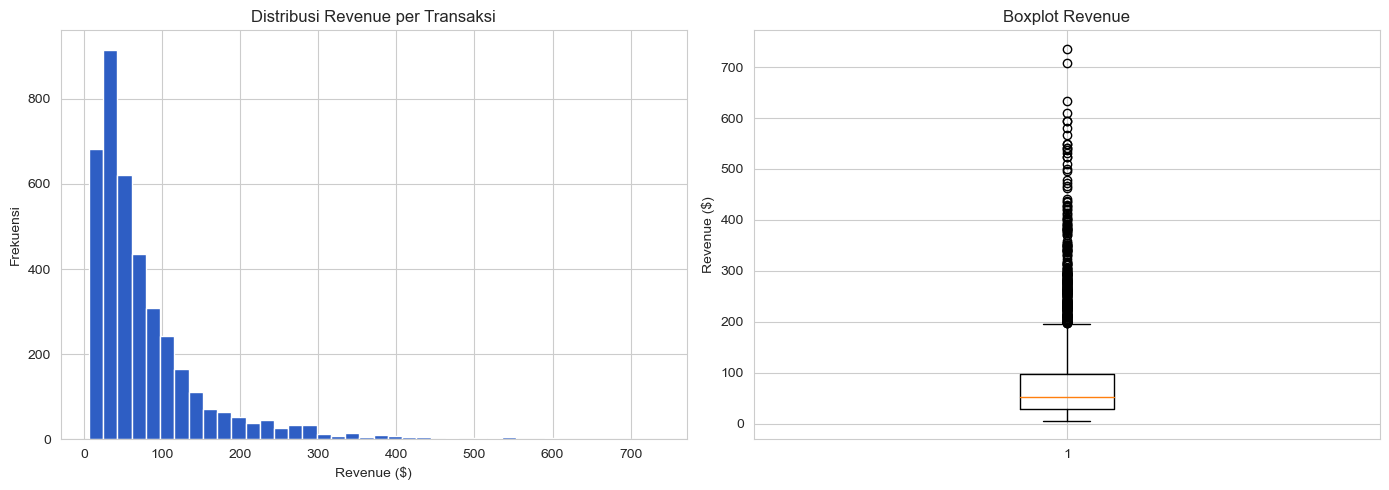

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram distribusi revenue
axes[0].hist(df['revenue'], bins=40, color='#2E5EC4', edgecolor='white')
axes[0].set_title('Distribusi Revenue per Transaksi')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Frekuensi')

# Boxplot revenue untuk lihat outlier
axes[1].boxplot(df['revenue'], vert=True)
axes[1].set_title('Boxplot Revenue')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

**Cara membaca chart ini:**
- **Histogram (kiri):** sumbu X = rentang nilai revenue (per USD 20), sumbu Y = jumlah transaksi di rentang itu. Batang tertinggi ada di sekitar USD 20-40 dengan tinggi ~900 — artinya sekitar 900 transaksi bernilai di rentang tersebut. Semakin ke kanan (mendekati USD 700), batangnya semakin pendek/nyaris rata dengan sumbu X — artinya semakin sedikit transaksi yang mencapai nilai setinggi itu.
- **Boxplot (kanan):** kotak di bagian bawah (sekitar USD 30-100) mewakili 50% transaksi yang paling umum. Garis oranye di dalam kotak adalah median (USD 52,84). Titik-titik bulat di atas garis USD 195 adalah outlier — setiap titik mewakili satu transaksi individual yang nilainya jauh di atas kebanyakan, menumpuk padat dari USD 200-500 lalu makin jarang sampai titik tertinggi di USD 735,55.

**Insight:** Distribusi revenue per transaksi sangat *right-skewed* — mayoritas transaksi bernilai di bawah USD 100, dengan puncak (mode) sekitar USD 30-50. Ekor panjang ke kanan dan banyak outlier di boxplot (transaksi di atas USD 200, hingga maksimum USD 735,55) menunjukkan sebagian kecil transaksi bernilai jauh lebih tinggi dari rata-rata — kemungkinan berasal dari kombinasi produk mahal (unit_price tinggi) dengan quantity lebih dari 1. Pola ini konsisten dengan mean revenue (USD 78,02) yang jauh lebih tinggi dari median (USD 52,84), ciri khas data yang skewed.

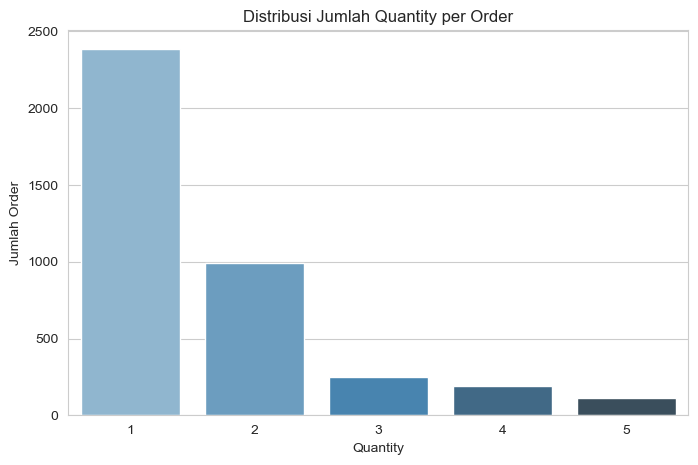

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='quantity', palette='Blues_d')
plt.title('Distribusi Jumlah Quantity per Order')
plt.xlabel('Quantity')
plt.ylabel('Jumlah Order')
plt.show()

**Insight:** Mayoritas order (sekitar 60%) hanya membeli 1 unit produk, dan jumlah order menurun konsisten seiring bertambahnya quantity — order dengan 5 unit jadi yang paling jarang. Pola ini menegaskan temuan dari Query 13 di Day 3: rendahnya Average Order Value (USD 78,33) bukan cuma soal harga produk yang murah, tapi juga karena mayoritas transaksi adalah pembelian tunggal (single-item purchase). Ini memperkuat peluang strategi bundling/cross-sell — mendorong customer membeli lebih dari 1 unit atau lebih dari 1 produk sekaligus berpotensi menaikkan AOV secara signifikan.

## 5. Analisis Kategori & Region

Visualisasi revenue berdasarkan kategori produk dan region untuk melihat kontributor utama penjualan.

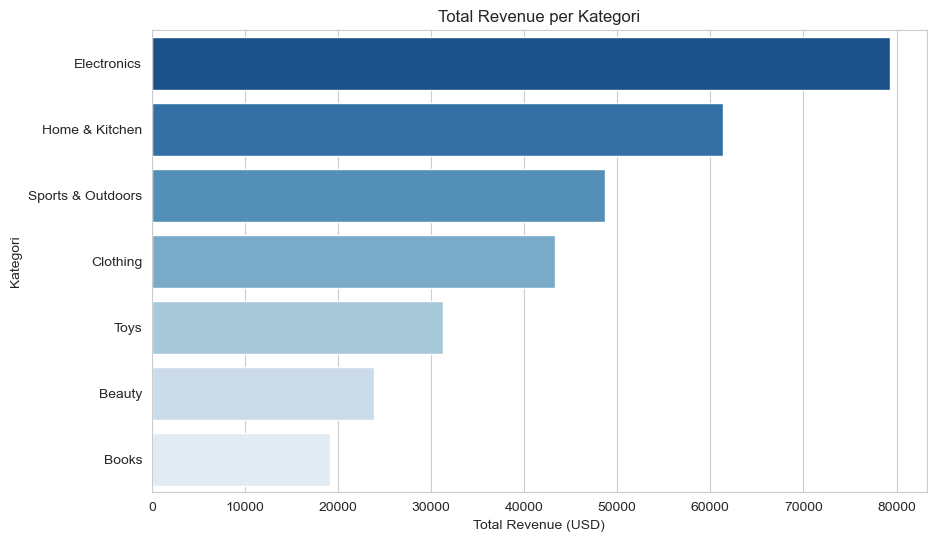

In [10]:
# Revenue per kategori
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='Blues_r')
plt.title('Total Revenue per Kategori')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Kategori')
plt.show()

**Insight:** Electronics jadi kategori dengan revenue tertinggi (sekitar USD 80.000), jauh di atas Home & Kitchen di posisi kedua. Books berada di posisi terakhir dengan revenue paling kecil. Perlu dicatat, angka di chart ini menghitung **seluruh order** (termasuk Cancelled/Returned/Pending), bukan cuma yang Completed seperti di analisis SQL Day 3 — sehingga nilainya lebih tinggi dari angka Query 12 (USD 63.888 untuk Electronics), tapi urutan rankingnya tetap sama persis. Ini jadi validasi tambahan bahwa Electronics memang secara konsisten jadi kategori paling kuat, di kondisi apa pun.

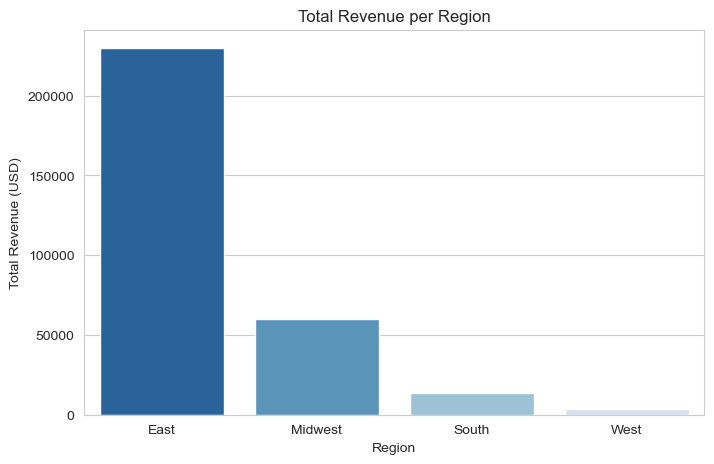

In [11]:
# Revenue per region
region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_revenue.index, y=region_revenue.values, palette='Blues_r')
plt.title('Total Revenue per Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue (USD)')
plt.show()

**Insight:** Region East mendominasi drastis dengan revenue mendekati USD 230.000, jauh melampaui Midwest, South, dan West yang bahkan hampir tidak terlihat di chart. Pola ketimpangan ekstrem ini konsisten dengan temuan Query 7 di Day 3 (East = 74,4% dari revenue Completed) — dan sekarang tervisualisasi jelas bahwa gap-nya bukan cuma besar secara persentase, tapi juga secara skala absolut. Region West yang nyaris tidak kelihatan di grafik ini jadi sinyal kuat bahwa ekspansi pasar ke luar East adalah salah satu area paling berisiko sekaligus paling berpeluang untuk bisnis ini.

## 6. Analisis Time Series

Visualisasi tren revenue bulanan sepanjang periode data (Jan 2023 - Des 2024) untuk melihat pola pertumbuhan dan musiman.

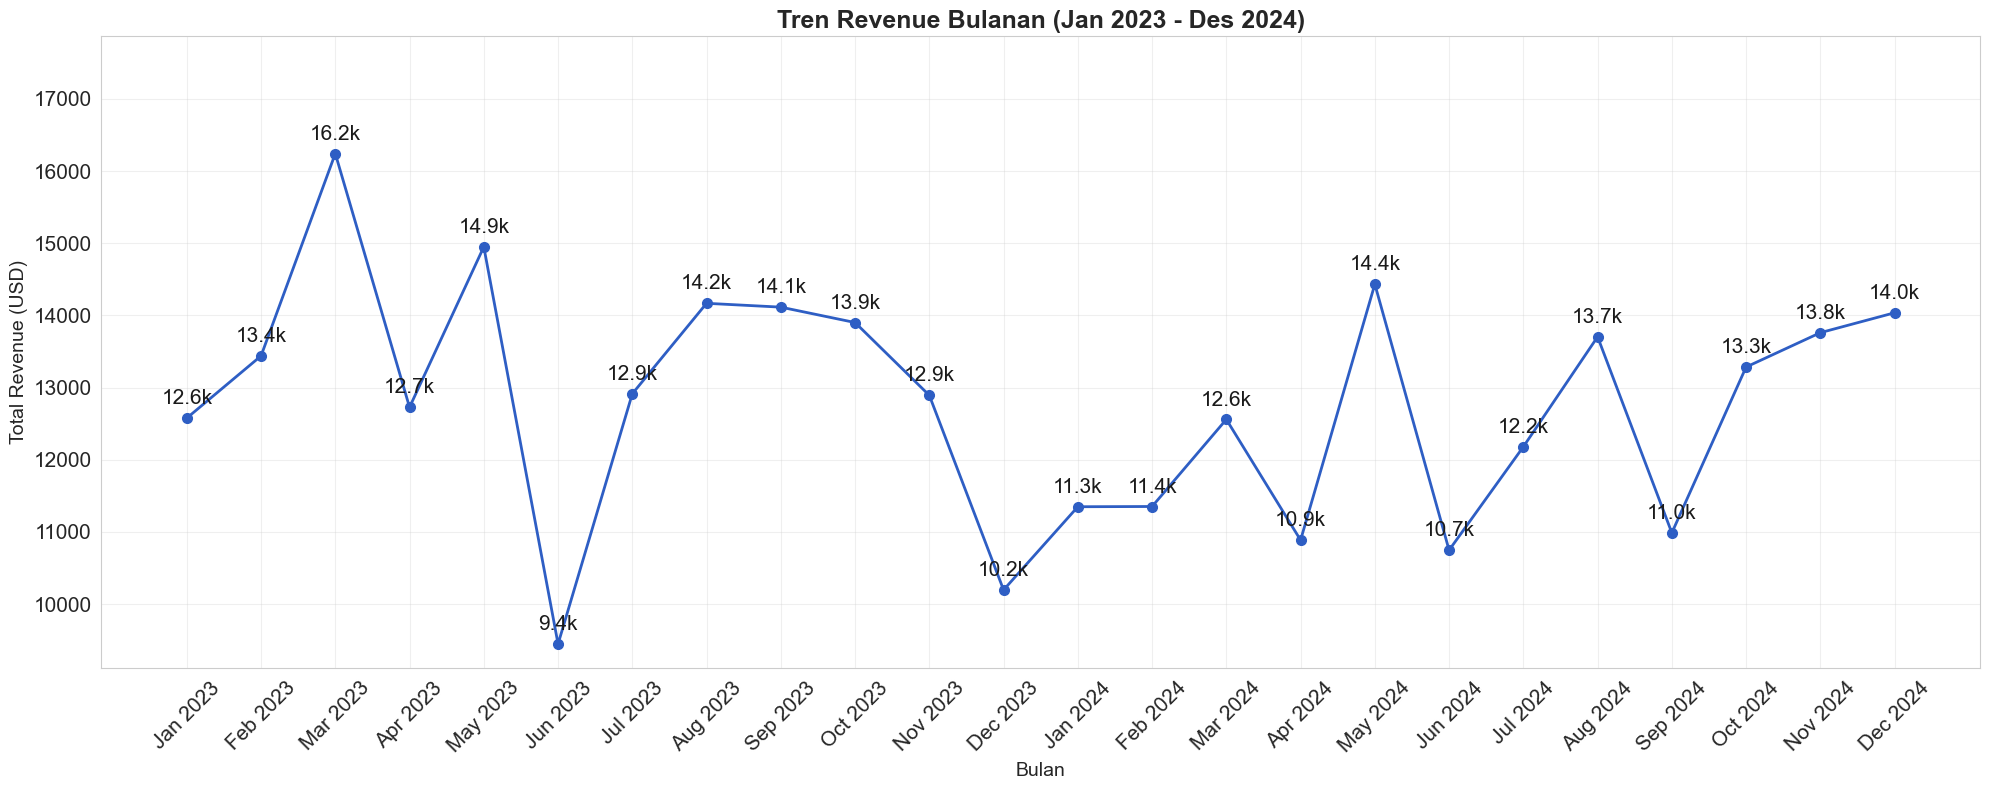

In [12]:
# Konversi order_date ke datetime
df['order_date'] = pd.to_datetime(df['order_date'], format='%m/%d/%Y')
df['year_month'] = df['order_date'].dt.to_period('M')

monthly_revenue = df.groupby('year_month')['revenue'].sum()

# Ubah index jadi string biasa (contoh: "Jan 2023") biar semua label seragam
monthly_revenue.index = monthly_revenue.index.strftime('%b %Y')

plt.figure(figsize=(20, 8))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='#2E5EC4', linewidth=2, markersize=7)
plt.title('Tren Revenue Bulanan (Jan 2023 - Des 2024)', fontsize=18, fontweight='bold')
plt.xlabel('Bulan', fontsize=14)
plt.ylabel('Total Revenue (USD)', fontsize=14)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, alpha=0.3)

# Kasih ruang ekstra di atas biar label angka nggak kepotong
plt.ylim(top=monthly_revenue.max() * 1.1)

# Tambahkan label angka di atas tiap titik
for i, value in enumerate(monthly_revenue.values):
    plt.annotate(f'{value/1000:.1f}k',
                 (i, value),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center',
                 fontsize=15,
                 color='#1A1A1A')

plt.tight_layout()
plt.show()

**Insight:** Tren revenue bulanan menunjukkan pola naik-turun yang tajam dan berulang sepanjang 24 bulan, tanpa arah musiman yang konsisten — puncak tertinggi terjadi di Maret 2023 (USD 16,2k) dan titik terendah di Juni 2023 (USD 9,4k), selisih hampir dua kali lipat hanya dalam rentang tiga bulan. Pola fluktuatif serupa (naik tajam lalu turun tajam) terulang beberapa kali, misalnya April-Juni 2024 (14,4k turun ke 10,7k) dan Juli-September 2024 (13,7k turun ke 11,0k). Visualisasi ini menjadi bukti visual langsung untuk temuan Query 11 di Day 3 (growth MoM antara -42,88% sampai +54,08%) — revenue bulanan memang tidak mengikuti pola musiman yang bisa diprediksi, kemungkinan lebih dipengaruhi faktor operasional atau acak dibanding tren jangka panjang.

## 7. Korelasi Antar Variabel

Melihat hubungan antar variabel numerik (quantity, unit_price, revenue) menggunakan heatmap korelasi.

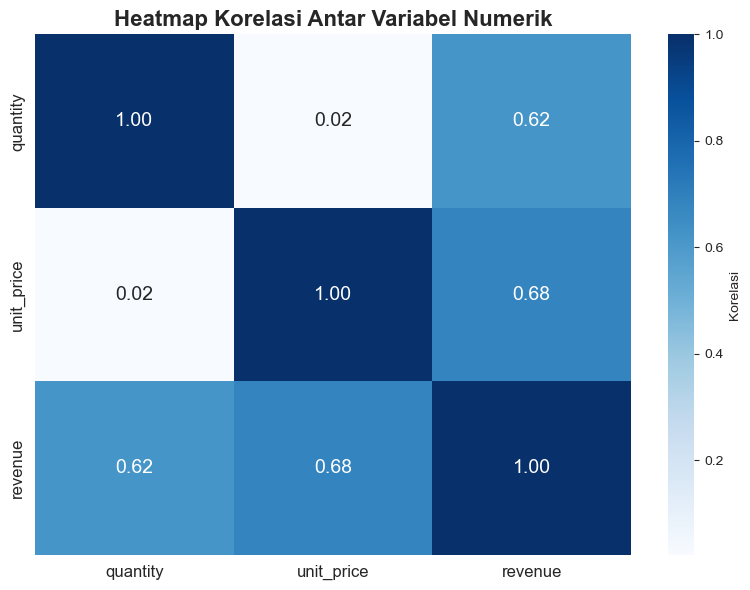

In [13]:
# Hitung matriks korelasi
corr_matrix = df[['quantity', 'unit_price', 'revenue']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f',
            annot_kws={'size': 14}, cbar_kws={'label': 'Korelasi'})
plt.title('Heatmap Korelasi Antar Variabel Numerik', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

**Insight:** Revenue berkorelasi cukup kuat dengan unit_price (0,68) dan quantity (0,62) — keduanya sama-sama jadi pendorong utama revenue, dengan harga produk sedikit lebih dominan. Yang menarik, korelasi antara unit_price dan quantity sendiri nyaris nol (0,02), artinya customer tidak cenderung membeli lebih banyak unit ketika harga produk lebih murah (atau sebaliknya) — keputusan "berapa banyak dibeli" dan "produk apa yang dipilih" tampak independen satu sama lain. Ini memperkuat insight dari Section 4: karena kebanyakan order cuma 1 unit (independen dari harga produknya), strategi menaikkan revenue lebih realistis lewat pendekatan cross-sell/bundling (menambah jumlah item per transaksi) dibanding berharap customer otomatis beli lebih banyak saat ada produk murah.

## 8. Kesimpulan EDA

Ringkasan temuan utama dari eksplorasi data menggunakan Python.

In [14]:
summary = {
    'Total Baris': df.shape[0],
    'Total Kolom': df.shape[1],
    'Missing Values': df.isnull().sum().sum(),
    'Baris Duplikat': df.duplicated().sum(),
    'Rata-rata Revenue': f"USD {df['revenue'].mean():.2f}",
    'Median Revenue': f"USD {df['revenue'].median():.2f}",
    'Kategori Terkuat': category_revenue.idxmax(),
    'Region Terkuat': region_revenue.idxmax(),
    'Korelasi Revenue-Unit Price': f"{corr_matrix.loc['revenue', 'unit_price']:.2f}",
    'Korelasi Revenue-Quantity': f"{corr_matrix.loc['revenue', 'quantity']:.2f}",
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metrik', 'Nilai'])
summary_df

,Metrik,Nilai
0,Total Baris,3933
1,Total Kolom,13
2,Missing Values,0
3,Baris Duplikat,0
4,Rata-rata Revenue,USD 78.02
5,Median Revenue,USD 52.84
6,Kategori Terkuat,Electronics
7,Region Terkuat,East
8,Korelasi Revenue-Unit Price,0.68
9,Korelasi Revenue-Quantity,0.62


### Ringkasan Temuan Utama

Eksplorasi data menggunakan Python pada dataset 3.933 baris ini menguatkan dan memperkaya temuan dari Day 2 (Excel) dan Day 3 (SQL) dengan sudut pandang statistik dan visual yang lebih mendalam:

1. **Distribusi revenue sangat right-skewed** — mayoritas transaksi bernilai kecil (di bawah USD 100), dengan beberapa outlier tinggi (maksimum USD 735,55) yang menarik rata-rata (USD 78,02) jauh di atas median (USD 52,84).

2. **Mayoritas order adalah pembelian tunggal** — sekitar 60% order hanya membeli 1 unit produk, menjelaskan mengapa Average Order Value tetap rendah meski ada variasi harga produk yang cukup lebar (USD 6 - USD 149,71).

3. **Electronics dan region East tetap dominan** di semua sudut analisis — konsisten dengan temuan SQL Day 3, memperkuat keandalan insight tersebut lintas metode analisis.

4. **Tren bulanan sangat fluktuatif tanpa pola musiman jelas** — visualisasi time series mengonfirmasi secara visual temuan growth MoM yang liar dari Day 3 (-42,88% hingga +54,08%).

5. **Revenue didorong seimbang oleh harga dan kuantitas** (korelasi 0,68 dan 0,62), namun keduanya nyaris independen satu sama lain (korelasi 0,02) — customer tidak otomatis membeli lebih banyak saat harga lebih murah, memperkuat peluang strategi bundling/cross-sell.

Notebook ini melengkapi rangkaian analisis Day 1-3 dan menjadi dasar untuk tahap selanjutnya: **Day 5 — Tableau Dashboard**, di mana temuan-temuan ini akan divisualisasikan dalam bentuk dashboard interaktif untuk business stakeholder.

---
*Notebook by Alya Shandy — Day 4 of 7-Day Data Analyst Portfolio Project*